# End-to-End Product Analytics

## 1. Data Familiarization

Before conducting any analysis, it is important to understand the structure of the available data. In this section, we inspect each table, identify its purpose, examine the available features, and look for any obvious data quality issues. This helps establish how the tables relate to one another and informs the analyses performed later in the project.

In [7]:
#Uploading the Dataset
import pandas as pd

events = pd.read_csv("data070726/events.csv")
category_tree = pd.read_csv("data070726/category_tree.csv")
item_properties_1 = pd.read_csv("data070726/item_properties_part1.csv")
item_properties_2 = pd.read_csv("data070726/item_properties_part2.csv")

In [25]:
events.head(n=5)

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [26]:
category_tree.head(n=5)

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [28]:
item_properties_1.head(n=5)

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [31]:
# Display basic information about each dataset.

datasets = {
    "Events": events,
    "Category Tree": category_tree,
    "Item Properties Part 1": item_properties_1,
    "Item Properties Part 2": item_properties_2
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\n")

Events
Shape: (2756101, 5)
Columns: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']

Missing Values:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


Category Tree
Shape: (1669, 2)
Columns: ['categoryid', 'parentid']

Missing Values:
categoryid     0
parentid      25
dtype: int64


Item Properties Part 1
Shape: (10999999, 4)
Columns: ['timestamp', 'itemid', 'property', 'value']

Missing Values:
timestamp    0
itemid       0
property     0
value        0
dtype: int64


Item Properties Part 2
Shape: (9275903, 4)
Columns: ['timestamp', 'itemid', 'property', 'value']

Missing Values:
timestamp    0
itemid       0
property     0
value        0
dtype: int64




## 2. Exploring the Events Table

The events table records every interaction between a visitor and the website. Each row represents a single event, such as viewing a product, adding a product to the cart, or completing a purchase. Understanding this table is essential because it forms the foundation for nearly all subsequent analyses.

In [11]:
# Display the first few rows of the events table.

events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [12]:
# Display summary information for the events table.

events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


## 3. Understanding User Events

Before analyzing user behavior, it is important to understand the types of interactions recorded in the dataset. Examining the distribution of event types provides insight into how users engage with the platform and establishes the foundation for later analyses such as conversion funnels and purchasing behavior.

In [14]:
# Count the number of each event type.

events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [15]:
# Display the percentage of each event type.

events["event"].value_counts(normalize=True) * 100

event
view           96.669607
addtocart       2.515583
transaction     0.814810
Name: proportion, dtype: float64

### Distribution of Event Types

To better understand user behavior, we visualize the frequency of each event type. This provides a quick overview of how users interact with the platform and highlights the relative rarity of purchasing events compared to browsing activity.

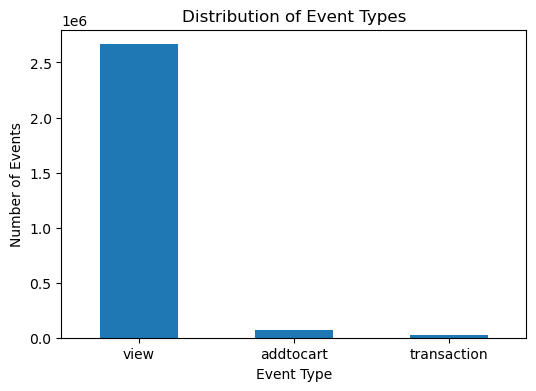

In [16]:
import matplotlib.pyplot as plt

event_counts = events["event"].value_counts()

plt.figure(figsize=(6, 4))
event_counts.plot(kind="bar")

plt.title("Distribution of Event Types")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")

plt.xticks(rotation=0)

plt.show()

## 4. Creating a SQL Database

While the original data is provided as CSV files, analysts typically work with relational databases rather than flat files. To simulate a real-world analytics workflow, the datasets are loaded into a SQLite database so that SQL can be used to answer business questions throughout the remainder of the project.

In [17]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")

events.to_sql(
    "events",
    conn,
    if_exists="replace",
    index=False
)

category_tree.to_sql(
    "category_tree",
    conn,
    if_exists="replace",
    index=False
)

1669

In [20]:
query = """
SELECT
    event,
    COUNT(*) AS event_count
FROM events
GROUP BY event;
"""

sql_result = pd.read_sql(query, conn)

sql_result

,event,event_count
0,addtocart,69332
1,transaction,22457
2,view,2664312


## 5. Understanding Platform Activity

Before performing more detailed analyses, it is useful to understand the overall scale of the platform. We begin by calculating several high-level metrics, including the number of unique visitors, unique products, and completed transactions. These metrics provide important context for interpreting user behavior throughout the remainder of the project.

In [22]:
query = """
SELECT
    COUNT(DISTINCT visitorid) AS unique_visitors,
    COUNT(DISTINCT itemid) AS unique_items,
    COUNT(DISTINCT transactionid) AS unique_transactions
FROM events;
"""

overview = pd.read_sql(query, conn)

overview

,unique_visitors,unique_items,unique_transactions
0,1407580,235061,17672


In [23]:
# Display key platform metrics.

print(f"Unique Visitors: {overview.loc[0, 'unique_visitors']:,}")
print(f"Unique Items: {overview.loc[0, 'unique_items']:,}")
print(f"Unique Transactions: {overview.loc[0, 'unique_transactions']:,}")

Unique Visitors: 1,407,580
Unique Items: 235,061
Unique Transactions: 17,672


## 6. Converting Timestamps

The event timestamps are currently stored as Unix timestamps in milliseconds, which are not easily interpretable. Converting them to standard datetime values allows us to analyze user activity over time and supports later analyses such as monthly trends, retention, and cohort analysis.

In [32]:
# Create a copy of the events table so we don't modify the original data.
events_clean = events.copy()

# Convert Unix timestamps (milliseconds) into readable datetime values.
events_clean["datetime"] = pd.to_datetime(
    events_clean["timestamp"],
    unit="ms"
)

# Display the first few converted timestamps.
events_clean[["timestamp", "datetime"]].head()

,timestamp,datetime
0,1433221332117,2015-06-02 05:02:12.117
1,1433224214164,2015-06-02 05:50:14.164
2,1433221999827,2015-06-02 05:13:19.827
3,1433221955914,2015-06-02 05:12:35.914
4,1433221337106,2015-06-02 05:02:17.106


In [33]:
# Check the overall time period covered by the dataset.

print("Earliest Event:", events_clean["datetime"].min())
print("Latest Event:  ", events_clean["datetime"].max())

Earliest Event: 2015-05-03 03:00:04.384000
Latest Event:   2015-09-18 02:59:47.788000


## 7. Platform Activity Over Time

After converting the timestamps into readable dates, we can begin examining how user activity changes over time. Understanding temporal patterns provides insight into user engagement and establishes a baseline before analyzing specific behaviors such as purchases or retention.

In [36]:
# Query daily platform activity from the SQLite database.
# The timestamp is divided by 1000 because it is stored in milliseconds.

query = """
SELECT
    DATE(timestamp / 1000, 'unixepoch') AS date,
    COUNT(*) AS event_count
FROM events
GROUP BY DATE(timestamp / 1000, 'unixepoch')
ORDER BY date;
"""

daily_events = pd.read_sql(query, conn)

daily_events.head()

,date,event_count
0,2015-05-03,13683
1,2015-05-04,19414
2,2015-05-05,23015
3,2015-05-06,23920
4,2015-05-07,23164


In [37]:
# Remove the final day because the dataset likely ends partway through that day,
# which creates a misleading artificial drop in activity.

daily_events_clean = daily_events.iloc[:-1].copy()

daily_events_clean.tail()

,date,event_count
133,2015-09-13,16859
134,2015-09-14,20913
135,2015-09-15,20427
136,2015-09-16,11495
137,2015-09-17,10128


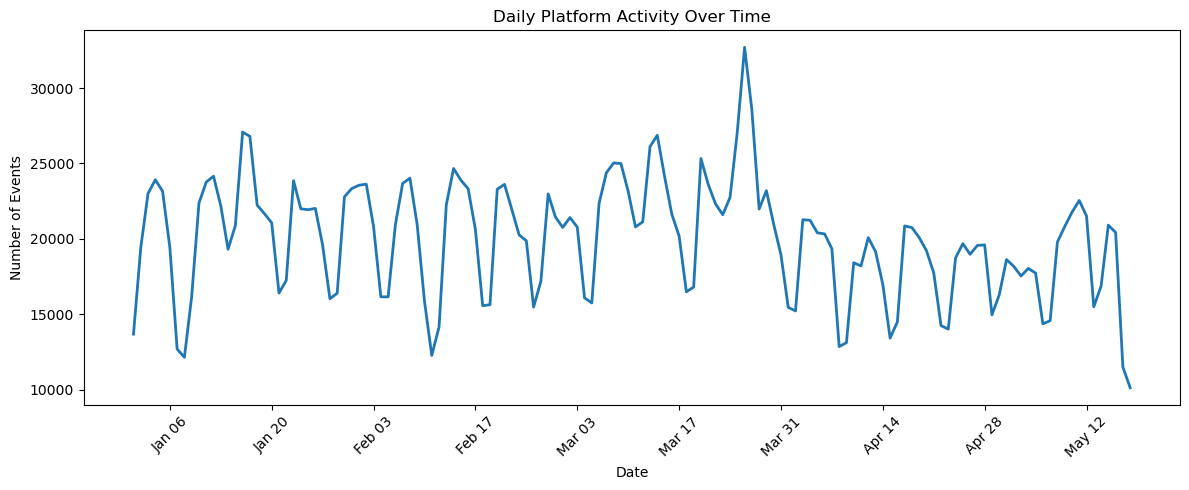

In [39]:
import matplotlib.dates as mdates

# Visualize daily platform activity after removing the incomplete final day.

plt.figure(figsize=(12, 5))

plt.plot(
    daily_events_clean["date"],
    daily_events_clean["event_count"],
    linewidth=2
)

plt.title("Daily Platform Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Events")

# Show a tick every two weeks.
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Daily platform activity remains relatively stable across the observation period, with recurring peaks and dips that suggest a weekly usage pattern. The analysis removes the final incomplete day to avoid misinterpreting a data cutoff as a true decline in user activity. Overall, the platform shows consistent engagement over time, providing a reasonable foundation for later analyses of conversion, retention, and customer behavior.

## 8. User Activity by Event Type

Overall platform activity provides a useful overview, but it does not distinguish between different types of user behavior. In this section, we examine how views, add-to-cart events, and purchases change over time to better understand user engagement throughout the observation period.

In [40]:
# Count each event type by day.

query = """
SELECT
    DATE(timestamp / 1000, 'unixepoch') AS date,
    event,
    COUNT(*) AS event_count
FROM events
GROUP BY DATE(timestamp / 1000, 'unixepoch'), event
ORDER BY date;
"""

daily_event_types = pd.read_sql(query, conn)

# Remove the final incomplete day.
daily_event_types = daily_event_types[
    daily_event_types["date"] != daily_event_types["date"].max()
]

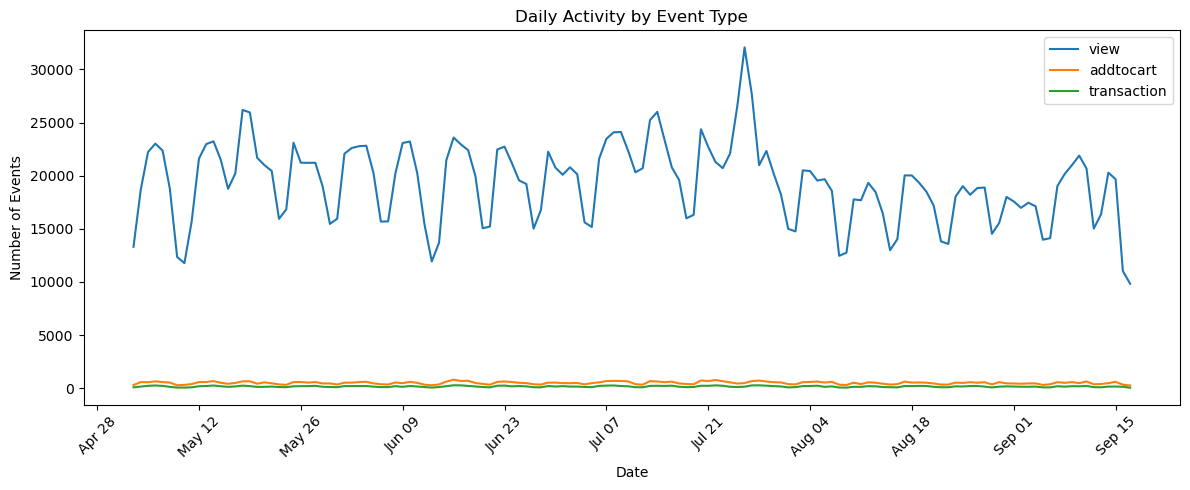

In [42]:
# Pivot the data so each event type becomes its own column.
daily_event_types_pivot = daily_event_types.pivot(
    index="date",
    columns="event",
    values="event_count"
).reset_index()

# Convert date strings into datetime objects so matplotlib handles the x-axis properly.
daily_event_types_pivot["date"] = pd.to_datetime(daily_event_types_pivot["date"])

plt.figure(figsize=(12, 5))

for event_type in ["view", "addtocart", "transaction"]:
    plt.plot(
        daily_event_types_pivot["date"],
        daily_event_types_pivot[event_type],
        label=event_type
    )

plt.title("Daily Activity by Event Type")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.legend()

# Show cleaner date labels.
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

Views account for the majority of daily platform activity, while add-to-cart and transaction events occur at much lower volumes. Daily views show recurring peaks and dips, suggesting a possible weekly usage pattern. Because purchases and cart additions are much smaller than views, they are difficult to compare on the same scale, so later analyses will focus on conversion rates rather than raw counts alone.

## 9. Conversion Funnel

A core objective of product analytics is understanding how users progress through the customer journey. Rather than focusing only on raw event counts, conversion rates help quantify how effectively users move from browsing products to adding them to their cart and ultimately completing a purchase.

In [43]:
# Calculate the number of each event type.

query = """
SELECT
    event,
    COUNT(*) AS event_count
FROM events
GROUP BY event;
"""

funnel = pd.read_sql(query, conn)

funnel

,event,event_count
0,addtocart,69332
1,transaction,22457
2,view,2664312


In [44]:
# Convert event counts into a dictionary for easy access.

counts = dict(zip(funnel["event"], funnel["event_count"]))

view_to_cart = counts["addtocart"] / counts["view"]
cart_to_purchase = counts["transaction"] / counts["addtocart"]
view_to_purchase = counts["transaction"] / counts["view"]

print(f"View → Add to Cart: {view_to_cart:.2%}")
print(f"Add to Cart → Purchase: {cart_to_purchase:.2%}")
print(f"View → Purchase: {view_to_purchase:.2%}")

View → Add to Cart: 2.60%
Add to Cart → Purchase: 32.39%
View → Purchase: 0.84%


In [45]:
# Create a small dataframe for visualizing the funnel conversion rates.

conversion_rates = pd.DataFrame({
    "Funnel Stage": [
        "View → Add to Cart",
        "Add to Cart → Purchase",
        "View → Purchase"
    ],
    "Conversion Rate": [
        view_to_cart,
        cart_to_purchase,
        view_to_purchase
    ]
})

conversion_rates

,Funnel Stage,Conversion Rate
0,View → Add to Cart,0.026022
1,Add to Cart → Purchase,0.323905
2,View → Purchase,0.008429


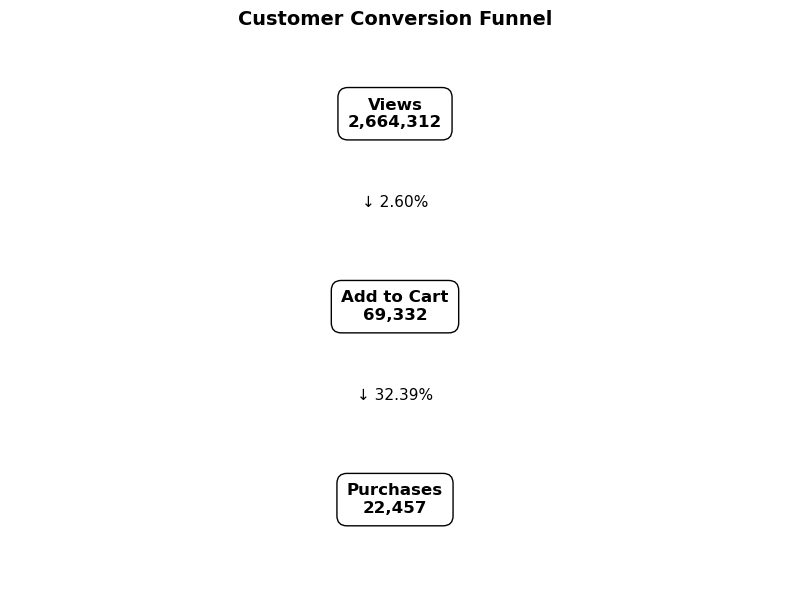

In [87]:
# Visualize the customer conversion funnel using equal-width stages.

funnel_counts = dict(zip(funnel["event"], funnel["event_count"]))

views = funnel_counts["view"]
addtocarts = funnel_counts["addtocart"]
purchases = funnel_counts["transaction"]

view_to_cart_rate = addtocarts / views
cart_to_purchase_rate = purchases / addtocarts

fig, ax = plt.subplots(figsize=(8, 6))

funnel_stages = [
    ("Views", views, None),
    ("Add to Cart", addtocarts, view_to_cart_rate),
    ("Purchases", purchases, cart_to_purchase_rate)
]

y_positions = [2.4, 1.2, 0.0]

for i, (stage, count, rate) in enumerate(funnel_stages):
    ax.text(
        0.5,
        y_positions[i],
        f"{stage}\n{count:,}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="black")
    )

    if i < len(funnel_stages) - 1:
        ax.annotate(
            f"↓ {funnel_stages[i + 1][2]:.2%}",
            xy=(0.5, y_positions[i] - 0.55),
            ha="center",
            va="center",
            fontsize=11
        )

ax.set_title("Customer Conversion Funnel", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 2.9)
ax.axis("off")

plt.tight_layout()
plt.show()

### Interpretation

The customer journey experiences its largest drop-off between product views and cart additions, with only **2.60%** of product views resulting in an item being added to the cart. In contrast, users who reach the cart stage demonstrate much stronger purchase intent, as nearly **one-third** of cart additions lead to a completed purchase. Overall, fewer than **1%** of product views ultimately convert into purchases, indicating that the vast majority of browsing sessions do not result in a transaction. These findings suggest that the greatest opportunity to improve overall conversion lies in increasing view-to-cart conversion, as even modest improvements at the top of the funnel would propagate through later stages and increase total purchases.

## 10. User-Level Purchasing Behavior

Event-level metrics show how often different actions occur, but they do not reveal how many individual visitors actually purchase. In this section, we shift from event counts to visitor-level behavior to understand what share of users make purchases and how purchasing users differ from non-purchasing users.

In [47]:
# Calculate visitor-level purchase behavior.

query = """
SELECT
    visitorid,
    COUNT(*) AS total_events,
    SUM(CASE WHEN event = 'view' THEN 1 ELSE 0 END) AS views,
    SUM(CASE WHEN event = 'addtocart' THEN 1 ELSE 0 END) AS addtocarts,
    SUM(CASE WHEN event = 'transaction' THEN 1 ELSE 0 END) AS transactions
FROM events
GROUP BY visitorid;
"""

visitor_behavior = pd.read_sql(query, conn)

visitor_behavior.head()

,visitorid,total_events,views,addtocarts,transactions
0,0,3,3,0,0
1,1,1,1,0,0
2,2,8,8,0,0
3,3,1,1,0,0
4,4,1,1,0,0


In [48]:
# Determine whether each visitor made at least one purchase.

visitor_behavior["made_purchase"] = (
    visitor_behavior["transactions"] > 0
)

In [49]:
# Summarize purchasing behavior across visitors.

purchase_summary = (
    visitor_behavior["made_purchase"]
    .value_counts()
    .rename_axis("Made Purchase")
    .reset_index(name="Visitors")
)

purchase_summary

,Made Purchase,Visitors
0,False,1395861
1,True,11719


In [50]:
# Calculate the percentage of visitors who made a purchase.

purchase_rate = (
    visitor_behavior["made_purchase"]
    .mean()
)

print(f"Visitor Purchase Rate: {purchase_rate:.2%}")

Visitor Purchase Rate: 0.83%


### Interpretation

Only 0.83% of visitors completed at least one purchase during the observation period, indicating that the vast majority of users interacted with the platform without converting. While this may initially appear low, it is common for large e-commerce websites where many visitors browse products without making a purchase. Measuring visitor-level purchasing behavior complements the earlier event-level funnel by focusing on customer outcomes rather than individual interactions.

## 11. Repeat Visitor Analysis

Not all visitors engage with the platform in the same way. In this section, we compare one-time visitors with returning visitors to better understand how engagement relates to purchasing behavior. This type of analysis is commonly used by product teams to identify valuable user segments and inform retention strategies.

In [53]:
# Summarize activity for each visitor.

query = """
WITH visitor_summary AS (
    SELECT
        visitorid,
        COUNT(*) AS total_events,
        SUM(CASE WHEN event = 'transaction' THEN 1 ELSE 0 END) AS transactions
    FROM events
    GROUP BY visitorid
)

SELECT
    CASE
        WHEN total_events = 1 THEN 'One-Time Visitor'
        WHEN total_events BETWEEN 2 AND 5 THEN 'Returning Visitor'
        ELSE 'Highly Active Visitor'
    END AS visitor_type,

    COUNT(*) AS visitors,
    AVG(total_events) AS avg_events,
    AVG(CASE WHEN transactions > 0 THEN 1.0 ELSE 0 END) AS purchase_rate

FROM visitor_summary
GROUP BY visitor_type
ORDER BY avg_events;
"""

visitor_segments = pd.read_sql(query, conn)

visitor_segments

,visitor_type,visitors,avg_events,purchase_rate
0,One-Time Visitor,1001560,1.000000,0.000070
1,Returning Visitor,347367,2.650911,0.014875
2,Highly Active Visitor,58653,14.214141,0.110514


## 12. Product Category Performance

Understanding which product categories generate the most purchasing activity can help identify where users are spending their time and where the business generates the greatest value. To answer this question, we combine user event data with product category information using SQL joins.

In [54]:
# Combine the two item property tables into a single dataframe.

item_properties = pd.concat(
    [item_properties_1, item_properties_2],
    ignore_index=True
)

item_properties.shape

(20275902, 4)

In [55]:
# Keep only category assignments for each item.

item_categories = item_properties[
    item_properties["property"] == "categoryid"
].copy()

item_categories.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
140,1432436400000,281245,categoryid,1277
151,1435460400000,35575,categoryid,1059
189,1437274800000,8313,categoryid,1147
197,1437879600000,55102,categoryid,47


In [56]:
# Load the item-category mapping into the SQLite database.

item_categories.to_sql(
    "item_categories",
    conn,
    if_exists="replace",
    index=False
)

788214

In [57]:
# Find the product categories with the most purchase events.

query = """
SELECT
    ic.value AS category_id,
    COUNT(*) AS purchases
FROM events e
JOIN item_categories ic
    ON e.itemid = ic.itemid
WHERE e.event = 'transaction'
GROUP BY ic.value
ORDER BY purchases DESC
LIMIT 10;
"""

top_categories = pd.read_sql(query, conn)

top_categories

,category_id,purchases
0,1509,2015
1,1613,1994
2,491,1528
3,1120,900
4,720,724
5,72,661
6,822,649
7,707,648
8,1277,637
9,959,532


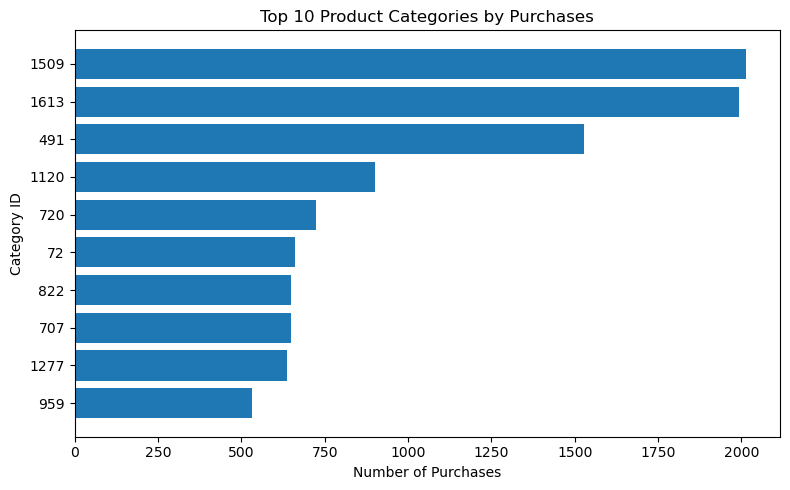

In [58]:
# Visualize the top product categories by purchase volume.

top_categories_plot = top_categories.sort_values("purchases")

plt.figure(figsize=(8, 5))

plt.barh(
    top_categories_plot["category_id"].astype(str),
    top_categories_plot["purchases"]
)

plt.title("Top 10 Product Categories by Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Category ID")

plt.tight_layout()
plt.show()

### Interpretation

Purchasing activity is concentrated among a relatively small set of product categories. Categories 1509 and 1613 generate the highest number of purchase events, followed by category 491. This suggests that a small number of product areas may account for a meaningful share of transaction activity, making them important candidates for merchandising, recommendation, or promotion strategies.

## 13. Category Conversion Performance

Purchase volume shows which categories generate the most transactions, but it does not show how efficiently categories convert user interest into purchases. In this section, we compare category-level views, cart additions, purchases, and conversion rates to identify categories that perform well relative to their traffic.

In [59]:
# Compare views, cart additions, purchases, and conversion rates by category.

query = """
SELECT
    ic.value AS category_id,
    COUNT(*) AS total_events,
    SUM(CASE WHEN e.event = 'view' THEN 1 ELSE 0 END) AS views,
    SUM(CASE WHEN e.event = 'addtocart' THEN 1 ELSE 0 END) AS addtocarts,
    SUM(CASE WHEN e.event = 'transaction' THEN 1 ELSE 0 END) AS purchases,
    1.0 * SUM(CASE WHEN e.event = 'addtocart' THEN 1 ELSE 0 END)
        / NULLIF(SUM(CASE WHEN e.event = 'view' THEN 1 ELSE 0 END), 0) AS view_to_cart_rate,
    1.0 * SUM(CASE WHEN e.event = 'transaction' THEN 1 ELSE 0 END)
        / NULLIF(SUM(CASE WHEN e.event = 'addtocart' THEN 1 ELSE 0 END), 0) AS cart_to_purchase_rate,
    1.0 * SUM(CASE WHEN e.event = 'transaction' THEN 1 ELSE 0 END)
        / NULLIF(SUM(CASE WHEN e.event = 'view' THEN 1 ELSE 0 END), 0) AS view_to_purchase_rate
FROM events e
JOIN item_categories ic
    ON e.itemid = ic.itemid
GROUP BY ic.value
HAVING views >= 1000
ORDER BY view_to_purchase_rate DESC
LIMIT 10;
"""

category_conversion = pd.read_sql(query, conn)

category_conversion

,category_id,total_events,views,addtocarts,purchases,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,57,2507,2229,128,150,0.057425,1.171875,0.067295
1,89,1817,1601,126,90,0.078701,0.714286,0.056215
2,1037,7562,6390,850,322,0.133020,0.378824,0.050391
3,103,1562,1386,109,67,0.078644,0.614679,0.048341
4,417,2204,1916,206,82,0.107516,0.398058,0.042797
5,686,6714,6052,426,236,0.070390,0.553991,0.038995
6,972,2213,1975,164,74,0.083038,0.451220,0.037468
7,1493,4880,4277,448,155,0.104746,0.345982,0.036240
8,833,5356,4869,313,174,0.064284,0.555911,0.035736
9,1072,1422,1267,110,45,0.086819,0.409091,0.035517


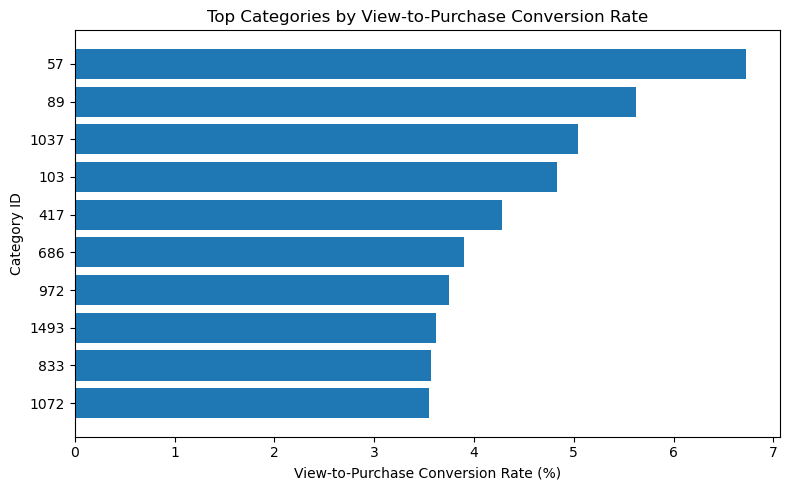

In [60]:
# Visualize the top categories by view-to-purchase conversion rate.

category_conversion_plot = category_conversion.sort_values("view_to_purchase_rate")

plt.figure(figsize=(8, 5))

plt.barh(
    category_conversion_plot["category_id"].astype(str),
    category_conversion_plot["view_to_purchase_rate"] * 100
)

plt.title("Top Categories by View-to-Purchase Conversion Rate")
plt.xlabel("View-to-Purchase Conversion Rate (%)")
plt.ylabel("Category ID")

plt.tight_layout()
plt.show()

## 14. Visitor Retention Analysis

Acquiring users is only one part of building a successful product. Long-term growth also depends on retaining users after their initial visit. In this section, we identify each visitor's first activity and measure whether they return on subsequent days.

In [61]:
# Determine each visitor's first activity date and assign an event order.

query = """
WITH visitor_events AS (
    SELECT
        visitorid,
        DATE(timestamp / 1000, 'unixepoch') AS event_date,
        ROW_NUMBER() OVER (
            PARTITION BY visitorid
            ORDER BY timestamp
        ) AS visit_number
    FROM events
)

SELECT *
FROM visitor_events
LIMIT 10;
"""

visitor_events = pd.read_sql(query, conn)

visitor_events

,visitorid,event_date,visit_number
0,0,2015-09-11,1
1,0,2015-09-11,2
2,0,2015-09-11,3
3,1,2015-08-13,1
4,2,2015-08-07,1
5,2,2015-08-07,2
6,2,2015-08-07,3
7,2,2015-08-07,4
8,2,2015-08-07,5
9,2,2015-08-07,6


### First Visit Date

To measure user retention, we first identify the initial day each visitor appeared on the platform. This allows later interactions to be compared against each visitor's starting point.

In [62]:
# Find the first activity date for every visitor.

query = """
SELECT
    visitorid,
    MIN(DATE(timestamp / 1000, 'unixepoch')) AS first_visit
FROM events
GROUP BY visitorid;
"""

first_visits = pd.read_sql(query, conn)

first_visits.head()

,visitorid,first_visit
0,0,2015-09-11
1,1,2015-08-13
2,2,2015-08-07
3,3,2015-08-01
4,4,2015-09-15


### Returning Visitors

After identifying each visitor's first activity date, we compare it with all subsequent activity to determine whether users returned after their initial visit. This provides a simple measure of customer retention.

In [63]:
# Determine whether each visitor returned after their first day.

query = """
WITH first_visit AS (
    SELECT
        visitorid,
        MIN(DATE(timestamp / 1000, 'unixepoch')) AS first_visit
    FROM events
    GROUP BY visitorid
)

SELECT
    f.visitorid,
    f.first_visit,
    MAX(
        CASE
            WHEN DATE(e.timestamp / 1000, 'unixepoch') > f.first_visit
            THEN 1
            ELSE 0
        END
    ) AS returned
FROM first_visit f
JOIN events e
    ON f.visitorid = e.visitorid
GROUP BY
    f.visitorid,
    f.first_visit;
"""

visitor_retention = pd.read_sql(query, conn)

visitor_retention.head()

,visitorid,first_visit,returned
0,0,2015-09-11,0
1,1,2015-08-13,0
2,2,2015-08-07,0
3,3,2015-08-01,0
4,4,2015-09-15,0


In [64]:
# Calculate the overall visitor retention rate.

retention_summary = (
    visitor_retention["returned"]
    .value_counts()
    .rename_axis("Returned")
    .reset_index(name="Visitors")
)

retention_summary

,Returned,Visitors
0,0,1263811
1,1,143769


In [65]:
# Calculate the percentage of visitors who returned after their first day.

retention_rate = visitor_retention["returned"].mean()

print(f"Visitor Retention Rate: {retention_rate:.2%}")

Visitor Retention Rate: 10.21%


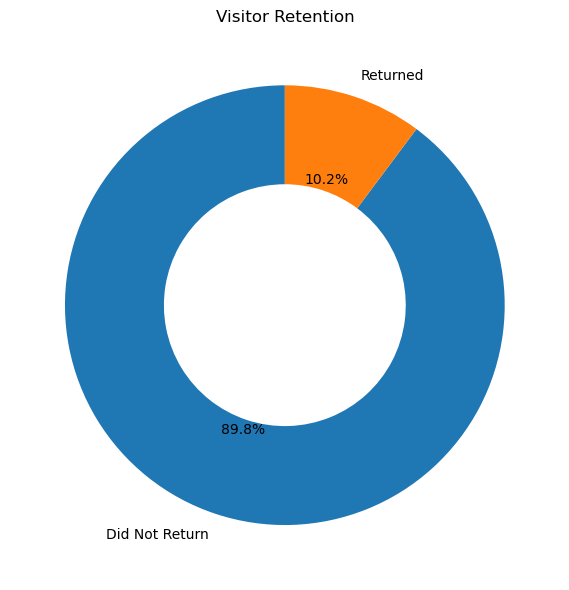

In [66]:
# Visualize visitor retention.

labels = ["Did Not Return", "Returned"]

plt.figure(figsize=(6, 6))

plt.pie(
    retention_summary["Visitors"],
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Visitor Retention")

plt.tight_layout()
plt.show()

### Interpretation

This analysis measures the proportion of visitors who returned after their initial day on the platform. Retention is one of the most important product metrics because sustainable growth depends not only on acquiring new users but also on encouraging existing users to return. A higher retention rate generally indicates stronger long-term user engagement.

## 15. Cohort Retention Analysis

Overall retention summarizes user behavior into a single percentage, but it does not show how engagement changes over time. Cohort analysis groups users by when they first joined the platform and measures how likely they are to return in later weeks, providing a richer view of long-term engagement.

In [67]:
# Create a table containing each visitor's first visit date
# alongside every day they were active.

query = """
WITH first_visit AS (
    SELECT
        visitorid,
        MIN(DATE(timestamp / 1000, 'unixepoch')) AS first_visit
    FROM events
    GROUP BY visitorid
)

SELECT DISTINCT
    e.visitorid,
    f.first_visit,
    DATE(e.timestamp / 1000, 'unixepoch') AS activity_date
FROM events e
JOIN first_visit f
    ON e.visitorid = f.visitorid
ORDER BY
    e.visitorid,
    activity_date;
"""

cohort_data = pd.read_sql(query, conn)

cohort_data.head(10)

,visitorid,first_visit,activity_date
0,0,2015-09-11,2015-09-11
1,1,2015-08-13,2015-08-13
2,2,2015-08-07,2015-08-07
3,3,2015-08-01,2015-08-01
4,4,2015-09-15,2015-09-15
5,5,2015-07-17,2015-07-17
6,6,2015-08-30,2015-08-30
7,6,2015-08-30,2015-08-31
8,7,2015-05-14,2015-05-14
9,7,2015-05-14,2015-05-16


In [68]:
# Convert dates to datetime objects for cohort calculations.

cohort_data["first_visit"] = pd.to_datetime(cohort_data["first_visit"])
cohort_data["activity_date"] = pd.to_datetime(cohort_data["activity_date"])


# Assign each visitor to a monthly cohort.

cohort_data["cohort_month"] = (
    cohort_data["first_visit"]
    .dt.to_period("M")
    .dt.to_timestamp()
)


# Calculate the number of months since each visitor first joined.

cohort_data["cohort_index"] = (
    (cohort_data["activity_date"].dt.year - cohort_data["first_visit"].dt.year) * 12
    + (cohort_data["activity_date"].dt.month - cohort_data["first_visit"].dt.month)
)

cohort_data.head(10)

,visitorid,first_visit,activity_date,cohort_month,cohort_index
0,0,2015-09-11,2015-09-11,2015-09-01,0
1,1,2015-08-13,2015-08-13,2015-08-01,0
2,2,2015-08-07,2015-08-07,2015-08-01,0
3,3,2015-08-01,2015-08-01,2015-08-01,0
4,4,2015-09-15,2015-09-15,2015-09-01,0
5,5,2015-07-17,2015-07-17,2015-07-01,0
6,6,2015-08-30,2015-08-30,2015-08-01,0
7,6,2015-08-30,2015-08-31,2015-08-01,0
8,7,2015-05-14,2015-05-14,2015-05-01,0
9,7,2015-05-14,2015-05-16,2015-05-01,0


In [69]:
# Count the number of active visitors for each cohort and month index.

cohort_counts = (
    cohort_data
    .groupby(["cohort_month", "cohort_index"])["visitorid"]
    .nunique()
    .reset_index(name="users")
)

cohort_counts.head(10)

,cohort_month,cohort_index,users
0,2015-05-01,0,307574
1,2015-05-01,1,14643
2,2015-05-01,2,8783
3,2015-05-01,3,5807
4,2015-05-01,4,3238
5,2015-06-01,0,299189
6,2015-06-01,1,12651
7,2015-06-01,2,6047
8,2015-06-01,3,2881
9,2015-07-01,0,355765


In [70]:
# Calculate cohort sizes (Month 0 users).

cohort_sizes = (
    cohort_counts[cohort_counts["cohort_index"] == 0]
    .set_index("cohort_month")["users"]
)

# Calculate retention rates for every cohort.

cohort_counts["retention_rate"] = cohort_counts.apply(
    lambda row: row["users"] / cohort_sizes[row["cohort_month"]],
    axis=1
)

cohort_counts.head(10)

,cohort_month,cohort_index,users,retention_rate
0,2015-05-01,0,307574,1.000000
1,2015-05-01,1,14643,0.047608
2,2015-05-01,2,8783,0.028556
3,2015-05-01,3,5807,0.018880
4,2015-05-01,4,3238,0.010528
5,2015-06-01,0,299189,1.000000
6,2015-06-01,1,12651,0.042284
7,2015-06-01,2,6047,0.020211
8,2015-06-01,3,2881,0.009629
9,2015-07-01,0,355765,1.000000


In [71]:
# Reshape the retention table into a matrix for visualization.

retention_matrix = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="retention_rate"
)

retention_matrix

cohort_index,0,1,2,3,4
cohort_month,,,,,
2015-05-01,1.0,0.047608,0.028556,0.018880,0.010528
2015-06-01,1.0,0.042284,0.020211,0.009629,NaN
2015-07-01,1.0,0.030768,0.010917,NaN,NaN
2015-08-01,1.0,0.024281,NaN,NaN,NaN
2015-09-01,1.0,NaN,NaN,NaN,NaN


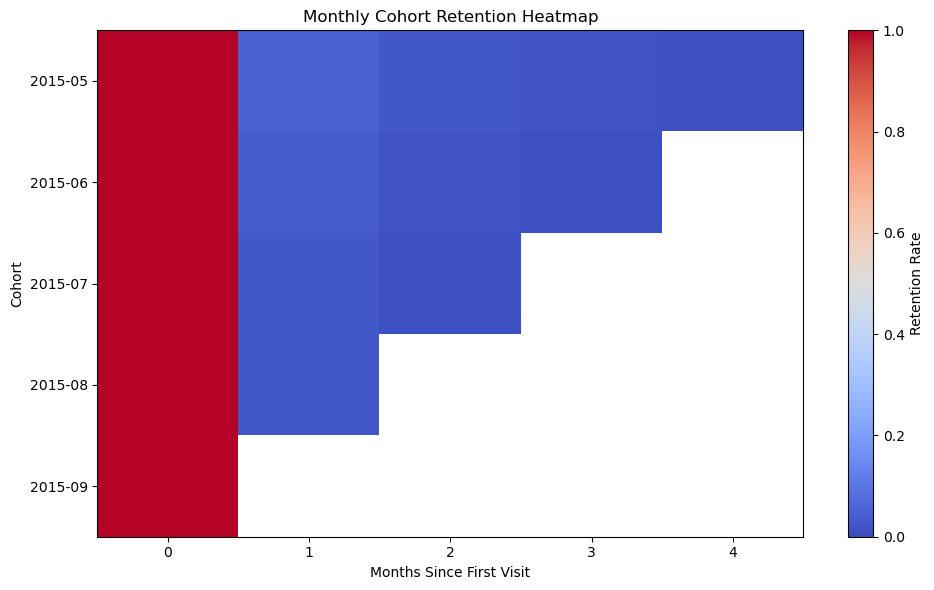

In [83]:
# Visualize cohort retention as a heatmap.

plt.figure(figsize=(10, 6))

plt.imshow(
    retention_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",   
    vmin=0,         
    vmax=1
)

plt.colorbar(label="Retention Rate")

plt.xticks(
    range(len(retention_matrix.columns)),
    retention_matrix.columns
)

plt.yticks(
    range(len(retention_matrix.index)),
    retention_matrix.index.strftime("%Y-%m")
)

plt.xlabel("Months Since First Visit")
plt.ylabel("Cohort")
plt.title("Monthly Cohort Retention Heatmap")

plt.tight_layout()
plt.show()

### Interpretation

Each row represents a cohort of users who first visited the platform during the same month. Each column shows the percentage of that cohort that remained active after a given number of months.

Across all cohorts, retention declines substantially after the first month, indicating that most users do not become long-term active customers. While some users continue returning over multiple months, retention drops quickly, suggesting that improving early user engagement may provide the greatest opportunity to increase long-term platform activity.

## 16. Executive KPI Dashboard

After exploring individual aspects of user behavior, we summarize the platform's most important performance metrics in a single dashboard. This provides a concise overview of user acquisition, engagement, conversion, and retention.

In [73]:
# Create a summary dashboard of key platform metrics.

dashboard = pd.DataFrame({
    "Metric": [
        "Unique Visitors",
        "Unique Items",
        "Unique Purchases",
        "Visitor Purchase Rate",
        "Visitor Retention Rate",
        "View → Purchase Rate"
    ],
    "Value": [
        f"{overview.loc[0, 'unique_visitors']:,}",
        f"{overview.loc[0, 'unique_items']:,}",
        f"{overview.loc[0, 'unique_transactions']:,}",
        f"{purchase_rate:.2%}",
        f"{retention_rate:.2%}",
        f"{view_to_purchase:.2%}"
    ]
})

dashboard

,Metric,Value
0,Unique Visitors,"1,407,580"
1,Unique Items,"235,061"
2,Unique Purchases,"17,672"
3,Visitor Purchase Rate,0.83%
4,Visitor Retention Rate,10.21%
5,View → Purchase Rate,0.84%


### Executive KPI Dashboard

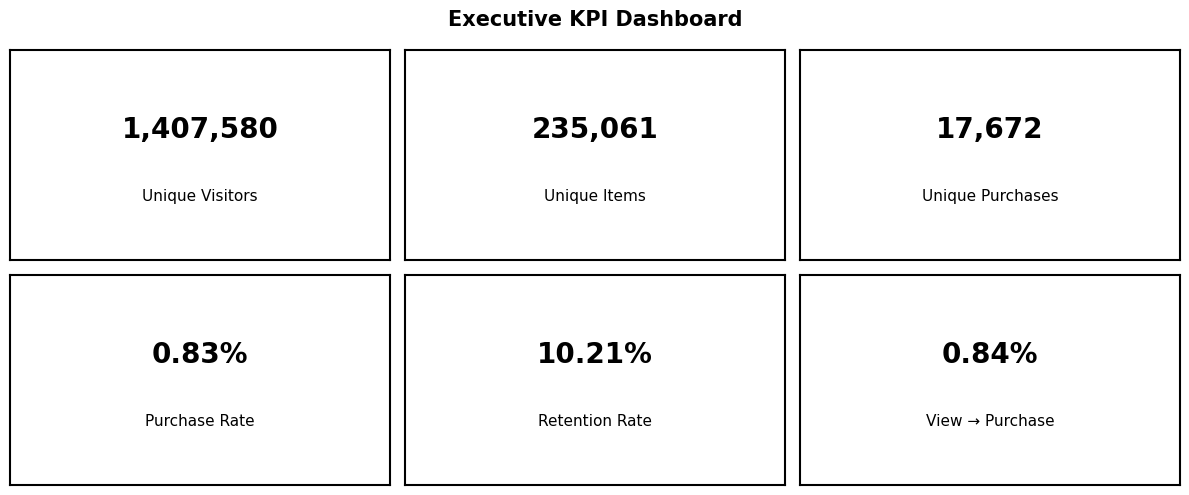

In [88]:
# Visualize the key platform KPIs as executive summary cards.

import matplotlib.pyplot as plt

cards = [
    ("Unique Visitors", f"{overview.loc[0, 'unique_visitors']:,}"),
    ("Unique Items", f"{overview.loc[0, 'unique_items']:,}"),
    ("Unique Purchases", f"{overview.loc[0, 'unique_transactions']:,}"),
    ("Purchase Rate", f"{purchase_rate:.2%}"),
    ("Retention Rate", f"{retention_rate:.2%}"),
    ("View → Purchase", f"{view_to_purchase:.2%}")
]

fig, axes = plt.subplots(2, 3, figsize=(12, 5))

for ax, (title, value) in zip(axes.flat, cards):

    ax.text(
        0.5,
        0.62,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.30,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

fig.suptitle("Executive KPI Dashboard", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

### Interpretation

The dashboard summarizes the platform's primary business metrics at a glance. While the platform attracts over 1.4 million unique visitors and exposes more than 235,000 products, only 0.83% of visitors ultimately complete a purchase. The retention rate of 10.21% suggests that relatively few users return after their initial visit, reinforcing retention as the platform's North Star Metric. Together, these KPIs provide a concise overview of acquisition, engagement, conversion, and long-term customer value.

## 17. Behavioral Segmentation

Different visitors interact with the platform in different ways. Segmenting users based on their behavior helps identify which groups contribute the most value and where targeted product improvements or marketing efforts may have the greatest impact.

In [74]:
# Create visitor-level behavior summaries using SQL.

query = """
SELECT
    visitorid,
    SUM(CASE WHEN event = 'view' THEN 1 ELSE 0 END) AS views,
    SUM(CASE WHEN event = 'addtocart' THEN 1 ELSE 0 END) AS addtocarts,
    SUM(CASE WHEN event = 'transaction' THEN 1 ELSE 0 END) AS purchases
FROM events
GROUP BY visitorid;
"""

visitor_segments = pd.read_sql(query, conn)

visitor_segments.head()

,visitorid,views,addtocarts,purchases
0,0,3,0,0
1,1,1,0,0
2,2,8,0,0
3,3,1,0,0
4,4,1,0,0


In [75]:
# Assign each visitor to a behavioral segment.

visitor_segments["segment"] = "Browser"

visitor_segments.loc[
    (visitor_segments["addtocarts"] > 0) &
    (visitor_segments["purchases"] == 0),
    "segment"
] = "Cart Abandoner"

visitor_segments.loc[
    visitor_segments["purchases"] > 0,
    "segment"
] = "Purchaser"

visitor_segments.loc[
    (visitor_segments["purchases"] > 1) &
    (visitor_segments["views"] >= visitor_segments["views"].quantile(0.90)),
    "segment"
] = "Power User"

In [76]:
# Count visitors in each behavioral segment.

segment_summary = (
    visitor_segments["segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Visitors")
)

segment_summary

,Segment,Visitors
0,Browser,1368715
1,Cart Abandoner,27146
2,Purchaser,9483
3,Power User,2236


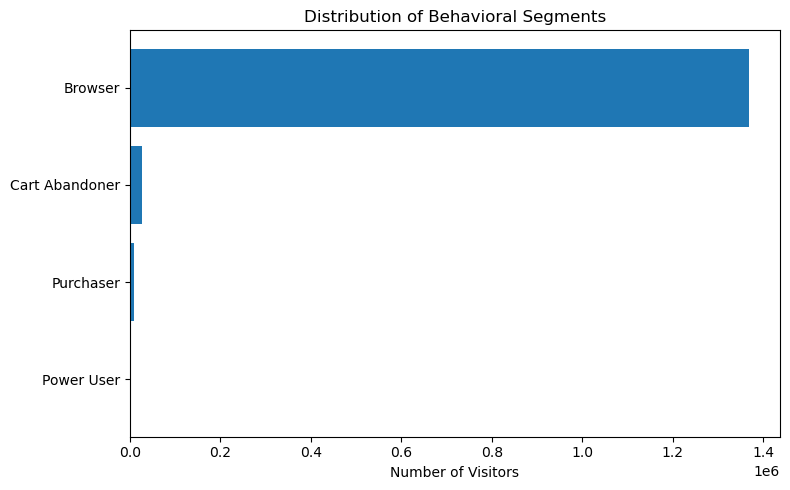

In [77]:
# Visualize the distribution of behavioral segments.

segment_plot = segment_summary.sort_values("Visitors")

plt.figure(figsize=(8, 5))

plt.barh(
    segment_plot["Segment"],
    segment_plot["Visitors"]
)

plt.title("Distribution of Behavioral Segments")
plt.xlabel("Number of Visitors")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Interpretation

Most visitors remained in the Browser segment, indicating that while many users explored products, relatively few progressed through the purchasing journey. Cart Abandoners represent a valuable opportunity for targeted interventions such as checkout optimization or reminder campaigns. Purchasers and Power Users account for a much smaller share of the user base but contribute the greatest direct business value, highlighting the importance of retaining these high-value customers.

## 18. Product Metrics & North Star Metric

Product teams rarely optimize every metric simultaneously. Instead, they define a **North Star Metric (NSM)** that best captures the long-term value delivered to users while monitoring supporting metrics that explain changes in performance.

The analyses throughout this project produced four primary product metrics:

In [78]:
# Summarize the primary product metrics.

product_metrics = pd.DataFrame({
    "Metric": [
        "Acquisition",
        "Conversion",
        "Retention",
        "Engagement"
    ],
    "Measured By": [
        "Unique Visitors",
        "Visitor Purchase Rate",
        "Visitor Retention Rate",
        "View → Purchase Rate"
    ],
    "Project Result": [
        f"{overview.loc[0, 'unique_visitors']:,}",
        f"{purchase_rate:.2%}",
        f"{retention_rate:.2%}",
        f"{view_to_purchase:.2%}"
    ]
})

product_metrics

,Metric,Measured By,Project Result
0,Acquisition,Unique Visitors,"1,407,580"
1,Conversion,Visitor Purchase Rate,0.83%
2,Retention,Visitor Retention Rate,10.21%
3,Engagement,View → Purchase Rate,0.84%


### North Star Metric

Based on the behavioral, conversion, and retention analyses presented throughout this project, Visitor Retention Rate is the strongest candidate for the platform's North Star Metric., **Visitor Retention Rate** is the strongest candidate for the platform's North Star Metric.

Unlike acquisition or purchase conversion, retention measures whether users continue finding value after their first interaction with the platform. Sustainable growth depends not only on attracting visitors but also on encouraging them to return over time.

The remaining metrics serve as supporting KPIs:

- **Acquisition:** Unique Visitors measure the platform's ability to attract new users.
- **Engagement:** View → Purchase Rate measures how efficiently browsing activity converts into completed purchases.
- **Conversion:** Visitor Purchase Rate measures the percentage of visitors who ultimately complete a transaction.

Retention is ultimately a lagging indicator of long-term product value. By increasing retention, the platform creates more opportunities for future purchases, higher customer lifetime value, and sustainable business growth. Throughout the remainder of this section, the supporting analyses are interpreted through the lens of improving this North Star Metric and the KPIs that influence it.

## 19. Product Analytics Framework (AARRR)

One of the most widely used frameworks in product analytics is the **AARRR (Pirate Metrics)** framework, which organizes product performance into five stages: Acquisition, Activation, Retention, Revenue, and Referral.

Although this dataset does not contain referral or marketing information, it allows us to evaluate the first four stages using the analyses performed throughout this project.

In [89]:
# Summarize the project's findings using the AARRR framework.

aarrr = pd.DataFrame({
    "Framework Stage": [
        "Acquisition",
        "Activation",
        "Retention",
        "Revenue"
    ],
    "Project Metric": [
        "Unique Visitors",
        "View → Purchase Funnel",
        "Visitor Retention Rate",
        "Completed Purchases"
    ],
    "Project Result": [
        f"{overview.loc[0, 'unique_visitors']:,}",
        f"{view_to_purchase:.2%}",
        f"{retention_rate:.2%}",
        f"{overview.loc[0, 'unique_transactions']:,}"
    ]
})

aarrr

,Framework Stage,Project Metric,Project Result
0,Acquisition,Unique Visitors,"1,407,580"
1,Activation,View → Purchase Funnel,0.84%
2,Retention,Visitor Retention Rate,10.21%
3,Revenue,Completed Purchases,"17,672"


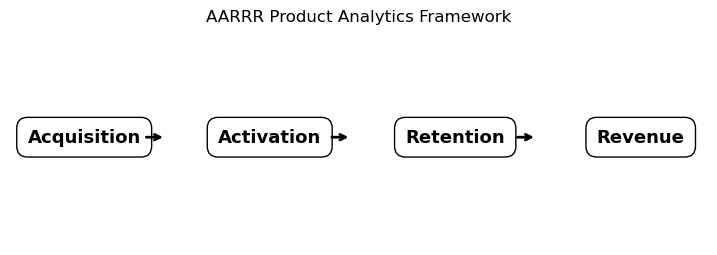

In [131]:
# Visualize the AARRR framework.

plt.figure(figsize=(9, 2.8))

plt.axis("off")

for i, stage in enumerate(aarrr["Framework Stage"]):
    x = i * 1.25

    plt.text(
        x,
        0,
        stage,
        ha="center",
        va="center",
        fontsize=13,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white")
    )

    if i < len(aarrr) - 1:
        plt.annotate(
            "",
            xy=(x + 0.55, 0),
            xytext=(x + 0.4, 0),
            arrowprops=dict(arrowstyle="->", lw=2)
        )

plt.xlim(-0.5, 4.2)
plt.ylim(-1, 1)

plt.title("AARRR Product Analytics Framework")

plt.show()

### Interpretation

The analyses completed throughout this project naturally map to the AARRR framework commonly used by product analytics teams.

The platform demonstrates strong **Acquisition**, attracting more than **1.4 million** unique visitors, but relatively few users ultimately progress through **Activation**, with less than **1%** of visitors completing a purchase. **Retention** analysis further revealed that only about **10%** of users return after their initial visit, limiting long-term engagement. Together, these findings suggest that improving activation and retention would likely have the greatest impact on sustainable platform growth.

## 20. Product Metrics Hierarchy

Product organizations rarely optimize a single metric in isolation. Instead, metrics are organized into a hierarchy where improving lower-level input metrics ultimately drives long-term business outcomes.

The analyses performed throughout this project can be organized into the following hierarchy.

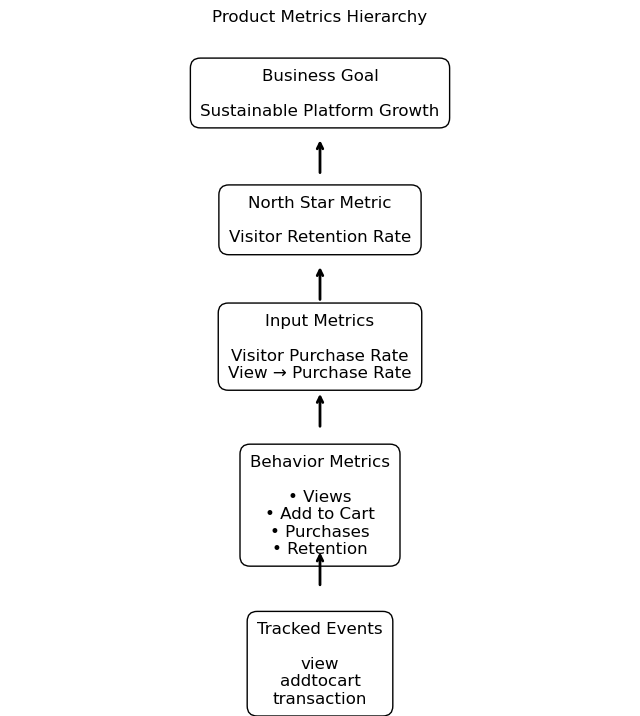

In [126]:
# Visualize the product metrics hierarchy.

plt.figure(figsize=(8, 7))
plt.axis("off")

levels = [
    ("Business Goal", "Sustainable Platform Growth"),
    ("North Star Metric", "Visitor Retention Rate"),
    ("Input Metrics", "Visitor Purchase Rate\nView → Purchase Rate"),
    ("Behavior Metrics", "• Views\n• Add to Cart\n• Purchases\n• Retention"),
    ("Tracked Events", "view\naddtocart\ntransaction")
]

y_positions = [8, 6, 4, 1.5, -1]

for (title, value), y in zip(levels, y_positions):

    plt.text(
        0.5,
        y,
        f"{title}\n\n{value}",
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white")
    )

    if y > 0:
        plt.annotate(
    "",
    xy=(0.5, y - 0.7),      # Arrow head
    xytext=(0.5, y - 1.3),  # Arrow tail
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    )
)

plt.xlim(0,1)
plt.ylim(0.5, 9)

plt.title("Product Metrics Hierarchy")

plt.show()

### Interpretation

The project began with raw user events (**views**, **cart additions**, and **purchases**) collected by the platform. These events were aggregated into behavioral metrics such as conversion rates and retention, which together influence the platform's primary input metrics.

Among these metrics, **Visitor Purchase Rate** and **View → Purchase Rate** are the most actionable because product teams can directly improve them through changes to search, recommendations, pricing, and checkout experiences. Improvements in these input metrics ultimately contribute to the project's selected North Star Metric—**Visitor Retention Rate**—which supports the broader business objective of sustainable long-term growth.

## 21. Experimentation Roadmap

Data analysis identifies opportunities for improvement, but product teams typically validate proposed changes through controlled experiments before deployment.

Based on the analyses performed throughout this project, the largest opportunity for improvement occurs between product views and cart additions. The following example demonstrates how this insight could be translated into an A/B testing plan.

In [127]:
# Create a sample experimentation roadmap.

experiment = pd.DataFrame({
    "Component": [
        "Hypothesis",
        "Product Change",
        "Primary Metric",
        "North Star Metric",
        "Guardrail Metrics",
        "Success Criteria"
    ],
    "Plan": [
        "Personalized recommendations increase cart additions.",
        "Display personalized products on product pages.",
        "View → Add-to-Cart Rate",
        "Visitor Retention Rate",
        "Purchase Rate, Error Rate, Visitor Retention",
        "≥5% lift in View → Add-to-Cart Rate with no meaningful decline in guardrail metrics."
    ]
})

experiment

,Component,Plan
0,Hypothesis,Personalized recommendations increase cart add...
1,Product Change,Display personalized products on product pages.
2,Primary Metric,View → Add-to-Cart Rate
3,North Star Metric,Visitor Retention Rate
4,Guardrail Metrics,"Purchase Rate, Error Rate, Visitor Retention"
5,Success Criteria,≥5% lift in View → Add-to-Cart Rate with no me...


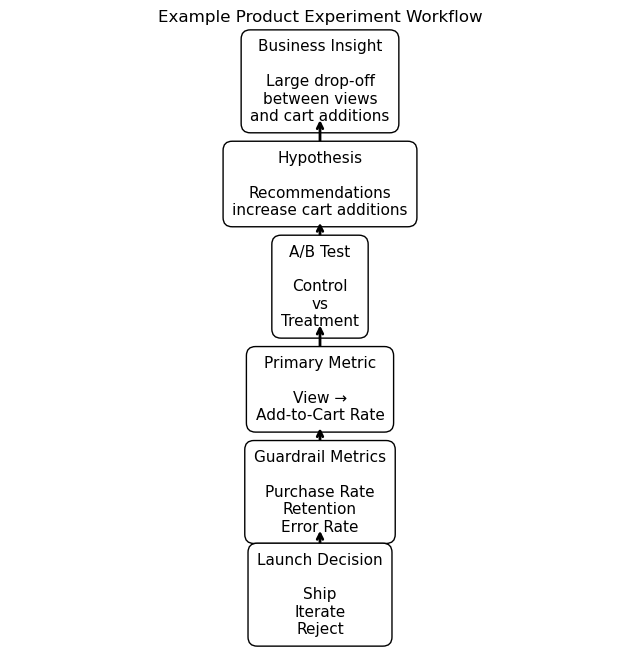

In [128]:
# Visualize the experimentation workflow.

plt.figure(figsize=(8, 8))
plt.axis("off")

steps = [
    "Business Insight",
    "Hypothesis",
    "A/B Test",
    "Primary Metric",
    "Guardrail Metrics",
    "Launch Decision"
]

descriptions = [
    "Large drop-off\nbetween views\nand cart additions",
    "Recommendations\nincrease cart additions",
    "Control\nvs\nTreatment",
    "View →\nAdd-to-Cart Rate",
    "Purchase Rate\nRetention\nError Rate",
    "Ship\nIterate\nReject"
]

y_positions = [10, 8, 6, 4, 2, 0]

for (title, desc), y in zip(zip(steps, descriptions), y_positions):

    plt.text(
        0.5,
        y,
        f"{title}\n\n{desc}",
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white")
    )

    if y > 0:
        plt.annotate(
            "",
            xy=(0.5, y-0.7),
            xytext=(0.5, y-1.3),
            arrowprops=dict(
                arrowstyle="->",
                lw=2
            )
        )

plt.xlim(0,1)
plt.ylim(-1,11)

plt.title("Example Product Experiment Workflow")

plt.show()

### Interpretation

The conversion funnel identified the largest opportunity for improvement between **product views** and **cart additions**, suggesting that users frequently browse products without demonstrating purchase intent.

Rather than immediately implementing product changes, a product analytics team would validate potential improvements through an **A/B test**. In this example, personalized product recommendations would be tested against the existing experience.

The experiment's **primary metric** would be the **View → Add-to-Cart Rate**, while **Purchase Rate**, **Visitor Retention**, and **Error Rate** would serve as **guardrail metrics** to ensure that improvements in one metric do not negatively impact the overall user experience.

Using controlled experimentation allows product decisions to be guided by statistically sound evidence instead of intuition alone.

## 22. Executive Recommendations

The analyses throughout this project identified several opportunities to improve product performance. The recommendations below are prioritized according to the largest opportunities observed in the data and reflect how a product analytics team would translate insights into action.

In [132]:
# Summarize the highest-priority product recommendations.

recommendations = pd.DataFrame({
    "Priority": [1, 2, 3, 4],
    "Recommendation": [
        "Increase View → Add-to-Cart Rate",
        "Reduce Cart Abandonment",
        "Improve Early Retention",
        "Retain High-Value Users"
    ],
    "Evidence": [
        "Only 2.60% of product views reached the cart.",
        "Nearly 27,000 visitors abandoned carts.",
        "Monthly retention declined rapidly after Month 0.",
        "Power Users represented a small but valuable segment."
    ],
    "Expected Business Impact": [
        "Increase total purchases",
        "Improve checkout conversion",
        "Increase long-term customer value",
        "Protect high-value revenue"
    ]
})

recommendations

,Priority,Recommendation,Evidence,Expected Business Impact
0,1,Increase View → Add-to-Cart Rate,Only 2.60% of product views reached the cart.,Increase total purchases
1,2,Reduce Cart Abandonment,"Nearly 27,000 visitors abandoned carts.",Improve checkout conversion
2,3,Improve Early Retention,Monthly retention declined rapidly after Month 0.,Increase long-term customer value
3,4,Retain High-Value Users,Power Users represented a small but valuable s...,Protect high-value revenue


### Interpretation

The analyses consistently point toward improving the earliest stages of the customer journey. Increasing the percentage of visitors who add products to their cart represents the largest opportunity because improvements at this stage affect every downstream metric.

Reducing cart abandonment provides the next largest opportunity by converting users who already demonstrated purchase intent. Improving early retention supports the project's selected North Star Metric, while retaining Power Users helps preserve the platform's highest-value customers.

Together, these recommendations prioritize initiatives with the greatest potential business impact while remaining directly supported by the analyses performed throughout the project.

## 23. Future Work

This analysis focused on understanding user behavior using historical event data. With additional data and experimentation capabilities, several extensions could provide deeper product insights and support more advanced decision-making.

In [133]:
# Summarize potential next steps for future product analytics.

future_work = pd.DataFrame({
    "Future Analysis": [
        "A/B Testing",
        "Customer Lifetime Value (LTV)",
        "Recommendation System Evaluation",
        "Predictive Modeling",
        "User Journey Analysis"
    ],
    "Business Value": [
        "Measure the causal impact of product changes.",
        "Estimate long-term customer value.",
        "Improve product discovery and purchase conversion.",
        "Identify users likely to churn or purchase.",
        "Discover common navigation paths leading to purchases."
    ]
})

future_work

,Future Analysis,Business Value
0,A/B Testing,Measure the causal impact of product changes.
1,Customer Lifetime Value (LTV),Estimate long-term customer value.
2,Recommendation System Evaluation,Improve product discovery and purchase convers...
3,Predictive Modeling,Identify users likely to churn or purchase.
4,User Journey Analysis,Discover common navigation paths leading to pu...


### Interpretation

The analyses completed in this project identify where product improvements should be made, while these future analyses explain how those improvements could be validated and expanded.

Controlled A/B testing would determine whether proposed product changes produce statistically significant improvements. Customer lifetime value analysis would help prioritize high-value users, recommendation system evaluation could improve product discovery, predictive models could identify at-risk users, and user journey analysis would reveal navigation patterns associated with successful purchases.

Together, these extensions represent a natural progression from descriptive analytics toward experimentation and predictive product analytics.

## 24. Conclusion

This project demonstrated an end-to-end product analytics workflow using SQL and Python. Beginning with raw event-level data, the analysis explored user behavior, conversion performance, customer retention, behavioral segmentation, product metrics, and experimentation strategy to identify opportunities for improving platform performance.

The analyses showed that the largest opportunity lies in increasing the percentage of users who progress from browsing products to adding items to their cart. Cohort analysis identified relatively low long-term retention, behavioral segmentation highlighted valuable Power Users and Cart Abandoners, and product metrics established Visitor Retention Rate as the platform's North Star Metric.

Overall, this project demonstrates how data can be transformed into actionable product decisions by combining SQL querying, Python analysis, visualization, and business-oriented interpretation. The resulting workflow reflects the type of analysis commonly performed by product data scientists to guide experimentation and long-term product strategy.